# Notebook 1 — Parse arXiv Metadata

Reads the raw arXiv JSONL snapshot and produces a cleaned DataFrame with one row per paper containing:
- `paper_id`, `year`, `subfield` (category prefix)
- `authors` (list of name strings)
- `region` (inferred from author last names via pycountry heuristics + affiliation keyword scan)

**Output:** `data/papers.csv`, `data/author_region_map.csv`

In [19]:
# Install dependencies if needed
# !pip install pandas tqdm

In [1]:
import json
import os
import re
import time
from collections import defaultdict
from pathlib import Path

import pandas as pd
from tqdm import tqdm

# ── CONFIG ──────────────────────────────────────────────────────────
ARXIV_PATH = "arxiv-metadata-oai-snapshot.json"   # update if needed
# Locate project root (works from any cwd)
def find_project_root():
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd()
    for parent in [start] + list(start.parents):
        candidate = parent / 'data'
        if candidate.exists() and any(candidate.iterdir()):
            return parent
    return Path.cwd()

ROOT = find_project_root()
OUT_DIR    = ROOT / 'data'
OUT_DIR.mkdir(exist_ok=True)

# Subfields to include (category prefix → display name)
SUBFIELD_MAP = {
    "cs"      : "Computer Science",
    "math"    : "Mathematics",
    "physics" : "Physics",
    "hep"     : "High Energy Physics",
    "astro"   : "Astrophysics",
    "cond"    : "Condensed Matter",
    "stat"    : "Statistics",
    "q-bio"   : "Quantitative Biology",
    "econ"    : "Economics",
}

def get_subfield(categories: str) -> str:
    """Return the display name for the primary category prefix."""
    if not categories:
        return "Other"
    primary = categories.split()[0]          # e.g. 'cs.LG'
    prefix  = primary.split(".")[0].lower()  # e.g. 'cs'
    # hep-ph, hep-th → 'hep'
    prefix = prefix.split("-")[0]
    return SUBFIELD_MAP.get(prefix, "Other")

def get_year(update_date: str) -> int:
    """Extract year from update_date string like '2021-03-15'."""
    try:
        return int(update_date[:4])
    except:
        return 0

print("Config loaded. ARXIV_PATH =", ARXIV_PATH)

Config loaded. ARXIV_PATH = arxiv-metadata-oai-snapshot.json


In [21]:
# ── COUNTRY INFERENCE ───────────────────────────────────────────────
# Keywords map directly to country names (Natural Earth standard names).
# The first matching keyword wins, so more specific terms come first.

COUNTRY_KEYWORDS = {
    # ── United States ───────────────────────────────────────────────
    'mit':          'United States of America',
    'harvard':      'United States of America',
    'stanford':     'United States of America',
    'berkeley':     'United States of America',
    'caltech':      'United States of America',
    'cornell':      'United States of America',
    'princeton':    'United States of America',
    'chicago':      'United States of America',
    'columbia':     'United States of America',
    'yale':         'United States of America',
    'nyu':          'United States of America',
    'ucla':         'United States of America',
    'michigan':     'United States of America',
    'carnegie':     'United States of America',
    'fermilab':     'United States of America',
    'uc santa':     'United States of America',
    'uc san':       'United States of America',
    'uc davis':     'United States of America',
    'penn state':   'United States of America',
    'johns hopkins':'United States of America',
    'duke':         'United States of America',
    'purdue':       'United States of America',
    'illinois':     'United States of America',
    'texas':        'United States of America',
    'washington':   'United States of America',
    'nasa':         'United States of America',
    'los alamos':   'United States of America',
    'slac':         'United States of America',
    'brookhaven':   'United States of America',
    'argonne':      'United States of America',
    # ── Canada ──────────────────────────────────────────────────────
    'toronto':      'Canada',
    'montreal':     'Canada',
    'waterloo':     'Canada',
    'mcgill':       'Canada',
    'ubc':          'Canada',
    'alberta':      'Canada',
    'canada':       'Canada',
    'perimeter':    'Canada',
    # ── United Kingdom ──────────────────────────────────────────────
    'oxford':       'United Kingdom',
    'cambridge':    'United Kingdom',
    'imperial':     'United Kingdom',
    'ucl':          'United Kingdom',
    'edinburgh':    'United Kingdom',
    'london':       'United Kingdom',
    'manchester':   'United Kingdom',
    'bristol':      'United Kingdom',
    'warwick':      'United Kingdom',
    'durham':       'United Kingdom',
    'ral ':         'United Kingdom',
    # ── Germany ─────────────────────────────────────────────────────
    'max planck':   'Germany',
    'berlin':       'Germany',
    'munich':       'Germany',
    'heidelberg':   'Germany',
    'hamburg':      'Germany',
    'desy':         'Germany',
    'dortmund':     'Germany',
    'bonn':         'Germany',
    'germany':      'Germany',
    # ── France ──────────────────────────────────────────────────────
    'paris':        'France',
    'sorbonne':     'France',
    'saclay':       'France',
    'grenoble':     'France',
    'cnrs':         'France',
    'inria':        'France',
    'france':       'France',
    # ── Switzerland ─────────────────────────────────────────────────
    'cern':         'Switzerland',
    'eth zurich':   'Switzerland',
    'epfl':         'Switzerland',
    'zurich':       'Switzerland',
    'switzerland':  'Switzerland',
    # ── Italy ───────────────────────────────────────────────────────
    'rome':         'Italy',
    'milan':        'Italy',
    'bologna':      'Italy',
    'padova':       'Italy',
    'infn':         'Italy',
    'italy':        'Italy',
    # ── Spain ───────────────────────────────────────────────────────
    'madrid':       'Spain',
    'barcelona':    'Spain',
    'spain':        'Spain',
    # ── Netherlands ─────────────────────────────────────────────────
    'amsterdam':    'Netherlands',
    'delft':        'Netherlands',
    'leiden':       'Netherlands',
    'utrecht':      'Netherlands',
    # ── Sweden ──────────────────────────────────────────────────────
    'stockholm':    'Sweden',
    'kth':          'Sweden',
    'chalmers':     'Sweden',
    'sweden':       'Sweden',
    # ── Russia ──────────────────────────────────────────────────────
    'moscow':       'Russia',
    'russia':       'Russia',
    'steklov':      'Russia',
    'novosibirsk':  'Russia',
    # ── China ───────────────────────────────────────────────────────
    'tsinghua':     'China',
    'peking':       'China',
    'fudan':        'China',
    'zhejiang':     'China',
    'beijing':      'China',
    'shanghai':     'China',
    'nanjing':      'China',
    'chinese':      'China',
    'china':        'China',
    'ustc':         'China',
    'cas ':         'China',
    'shenzhen':     'China',
    'wuhan':        'China',
    # ── Japan ───────────────────────────────────────────────────────
    'tokyo':        'Japan',
    'kyoto':        'Japan',
    'osaka':        'Japan',
    'tohoku':       'Japan',
    'riken':        'Japan',
    'kek':          'Japan',
    'japan':        'Japan',
    # ── South Korea ─────────────────────────────────────────────────
    'seoul':        'South Korea',
    'kaist':        'South Korea',
    'postech':      'South Korea',
    'korea':        'South Korea',
    # ── Taiwan ──────────────────────────────────────────────────────
    'taiwan':       'Taiwan',
    'academia sinica': 'Taiwan',
    # ── India ───────────────────────────────────────────────────────
    'iit':          'India',
    'tifr':         'India',
    'iisc':         'India',
    'india':        'India',
    # ── Singapore ───────────────────────────────────────────────────
    'singapore':    'Singapore',
    'nus':          'Singapore',
    'ntu':          'Singapore',
    # ── Brazil ──────────────────────────────────────────────────────
    'usp':          'Brazil',
    'unicamp':      'Brazil',
    'brazil':       'Brazil',
    # ── Argentina ───────────────────────────────────────────────────
    'argentina':    'Argentina',
    'buenos aires': 'Argentina',
    # ── Mexico ──────────────────────────────────────────────────────
    'mexico':       'Mexico',
    'unam':         'Mexico',
    # ── Israel ──────────────────────────────────────────────────────
    'israel':       'Israel',
    'weizmann':     'Israel',
    'technion':     'Israel',
    'hebrew':       'Israel',
    # ── Iran ────────────────────────────────────────────────────────
    'tehran':       'Iran',
    'iran':         'Iran',
    # ── Turkey ──────────────────────────────────────────────────────
    'istanbul':     'Turkey',
    'ankara':       'Turkey',
    'turkey':       'Turkey',
    # ── South Africa ────────────────────────────────────────────────
    'south africa': 'South Africa',
    'cape town':    'South Africa',
    # ── Australia ───────────────────────────────────────────────────
    'sydney':       'Australia',
    'melbourne':    'Australia',
    'anu':          'Australia',
    'australia':    'Australia',
    # ── Egypt ───────────────────────────────────────────────────────
    'cairo':        'Egypt',
    'egypt':        'Egypt',
    # ── Poland ──────────────────────────────────────────────────────
    'warsaw':       'Poland',
    'krakow':       'Poland',
    'poland':       'Poland',
    # ── Austria ─────────────────────────────────────────────────────
    'vienna':       'Austria',
    'austria':      'Austria',
    # ── Saudi Arabia ────────────────────────────────────────────────
    'saudi':        'Saudi Arabia',
    'kaust':        'Saudi Arabia',
}

# Country → Region lookup (for backward compatibility)
COUNTRY_TO_REGION = {
    'United States of America': 'North America', 'Canada': 'North America',
    'United Kingdom': 'Europe', 'Germany': 'Europe', 'France': 'Europe',
    'Switzerland': 'Europe', 'Italy': 'Europe', 'Spain': 'Europe',
    'Netherlands': 'Europe', 'Sweden': 'Europe', 'Russia': 'Europe',
    'Poland': 'Europe', 'Austria': 'Europe',
    'China': 'East Asia', 'Japan': 'East Asia', 'South Korea': 'East Asia', 'Taiwan': 'East Asia',
    'India': 'South Asia', 'Singapore': 'South Asia',
    'Brazil': 'Latin America', 'Argentina': 'Latin America', 'Mexico': 'Latin America',
    'Israel': 'Middle East', 'Iran': 'Middle East', 'Turkey': 'Middle East', 'Saudi Arabia': 'Middle East',
    'South Africa': 'Africa/ME', 'Egypt': 'Africa/ME',
    'Australia': 'Oceania',
}

def infer_country(authors_raw: str) -> str:
    """Scan raw author string for institution/country keywords → country name."""
    if not isinstance(authors_raw, str) or not authors_raw.strip():
        return 'Unknown'
    text = authors_raw.lower()
    for kw, country in COUNTRY_KEYWORDS.items():
        if kw in text:
            return country
    return 'Unknown'

print(f'Country keyword dictionary: {len(COUNTRY_KEYWORDS)} entries covering {len(set(COUNTRY_KEYWORDS.values()))} countries')


Country keyword dictionary: 155 entries covering 29 countries


In [22]:
# ── PARSE LOOP ───────────────────────────────────────────────────────
records  = []
YEAR_MIN, YEAR_MAX = 1991, 2025
MAX_LINES = None   # set to e.g. 200_000 for a quick test run

t0 = time.time()
with open(ARXIV_PATH, 'r') as f:
    for i, line in enumerate(tqdm(f, total=2_400_000, desc='Parsing')):
        if MAX_LINES and i >= MAX_LINES:
            break
        rec  = json.loads(line)
        year = get_year(rec.get('update_date', ''))
        if year < YEAR_MIN or year > YEAR_MAX:
            continue

        subfield    = get_subfield(rec.get('categories', ''))
        authors_raw = rec.get('authors', '')
        country     = infer_country(authors_raw)
        region      = COUNTRY_TO_REGION.get(country, 'Unknown')

        authors_parsed = rec.get('authors_parsed') or []
        author_names = [
            f"{a[0]}, {a[1]}" for a in authors_parsed
            if len(a) >= 2 and a[0] and a[1]
        ]
        records.append({
            'paper_id'    : rec.get('id', ''),
            'year'        : year,
            'subfield'    : subfield,
            'country'     : country,
            'region'      : region,
            'author_count': len(author_names),
            'authors'     : '|'.join(author_names),
        })

print(f'\nParsed {len(records):,} papers in {time.time()-t0:.1f}s')


Parsing: 3008380it [01:25, 35010.02it/s]                             


Parsed 2,872,364 papers in 86.0s


In [23]:
# ── COUNTRY INFERENCE ───────────────────────────────────────────────
# Keywords map directly to country names (Natural Earth standard names).
# The first matching keyword wins, so more specific terms come first.

COUNTRY_KEYWORDS = {
    # ── United States ───────────────────────────────────────────────
    'mit':          'United States of America',
    'harvard':      'United States of America',
    'stanford':     'United States of America',
    'berkeley':     'United States of America',
    'caltech':      'United States of America',
    'cornell':      'United States of America',
    'princeton':    'United States of America',
    'chicago':      'United States of America',
    'columbia':     'United States of America',
    'yale':         'United States of America',
    'nyu':          'United States of America',
    'ucla':         'United States of America',
    'michigan':     'United States of America',
    'carnegie':     'United States of America',
    'fermilab':     'United States of America',
    'uc santa':     'United States of America',
    'uc san':       'United States of America',
    'uc davis':     'United States of America',
    'penn state':   'United States of America',
    'johns hopkins':'United States of America',
    'duke':         'United States of America',
    'purdue':       'United States of America',
    'illinois':     'United States of America',
    'texas':        'United States of America',
    'washington':   'United States of America',
    'nasa':         'United States of America',
    'los alamos':   'United States of America',
    'slac':         'United States of America',
    'brookhaven':   'United States of America',
    'argonne':      'United States of America',
    # ── Canada ──────────────────────────────────────────────────────
    'toronto':      'Canada',
    'montreal':     'Canada',
    'waterloo':     'Canada',
    'mcgill':       'Canada',
    'ubc':          'Canada',
    'alberta':      'Canada',
    'canada':       'Canada',
    'perimeter':    'Canada',
    # ── United Kingdom ──────────────────────────────────────────────
    'oxford':       'United Kingdom',
    'cambridge':    'United Kingdom',
    'imperial':     'United Kingdom',
    'ucl':          'United Kingdom',
    'edinburgh':    'United Kingdom',
    'london':       'United Kingdom',
    'manchester':   'United Kingdom',
    'bristol':      'United Kingdom',
    'warwick':      'United Kingdom',
    'durham':       'United Kingdom',
    'ral ':         'United Kingdom',
    # ── Germany ─────────────────────────────────────────────────────
    'max planck':   'Germany',
    'berlin':       'Germany',
    'munich':       'Germany',
    'heidelberg':   'Germany',
    'hamburg':      'Germany',
    'desy':         'Germany',
    'dortmund':     'Germany',
    'bonn':         'Germany',
    'germany':      'Germany',
    # ── France ──────────────────────────────────────────────────────
    'paris':        'France',
    'sorbonne':     'France',
    'saclay':       'France',
    'grenoble':     'France',
    'cnrs':         'France',
    'inria':        'France',
    'france':       'France',
    # ── Switzerland ─────────────────────────────────────────────────
    'cern':         'Switzerland',
    'eth zurich':   'Switzerland',
    'epfl':         'Switzerland',
    'zurich':       'Switzerland',
    'switzerland':  'Switzerland',
    # ── Italy ───────────────────────────────────────────────────────
    'rome':         'Italy',
    'milan':        'Italy',
    'bologna':      'Italy',
    'padova':       'Italy',
    'infn':         'Italy',
    'italy':        'Italy',
    # ── Spain ───────────────────────────────────────────────────────
    'madrid':       'Spain',
    'barcelona':    'Spain',
    'spain':        'Spain',
    # ── Netherlands ─────────────────────────────────────────────────
    'amsterdam':    'Netherlands',
    'delft':        'Netherlands',
    'leiden':       'Netherlands',
    'utrecht':      'Netherlands',
    # ── Sweden ──────────────────────────────────────────────────────
    'stockholm':    'Sweden',
    'kth':          'Sweden',
    'chalmers':     'Sweden',
    'sweden':       'Sweden',
    # ── Russia ──────────────────────────────────────────────────────
    'moscow':       'Russia',
    'russia':       'Russia',
    'steklov':      'Russia',
    'novosibirsk':  'Russia',
    # ── China ───────────────────────────────────────────────────────
    'tsinghua':     'China',
    'peking':       'China',
    'fudan':        'China',
    'zhejiang':     'China',
    'beijing':      'China',
    'shanghai':     'China',
    'nanjing':      'China',
    'chinese':      'China',
    'china':        'China',
    'ustc':         'China',
    'cas ':         'China',
    'shenzhen':     'China',
    'wuhan':        'China',
    # ── Japan ───────────────────────────────────────────────────────
    'tokyo':        'Japan',
    'kyoto':        'Japan',
    'osaka':        'Japan',
    'tohoku':       'Japan',
    'riken':        'Japan',
    'kek':          'Japan',
    'japan':        'Japan',
    # ── South Korea ─────────────────────────────────────────────────
    'seoul':        'South Korea',
    'kaist':        'South Korea',
    'postech':      'South Korea',
    'korea':        'South Korea',
    # ── Taiwan ──────────────────────────────────────────────────────
    'taiwan':       'Taiwan',
    'academia sinica': 'Taiwan',
    # ── India ───────────────────────────────────────────────────────
    'iit':          'India',
    'tifr':         'India',
    'iisc':         'India',
    'india':        'India',
    # ── Singapore ───────────────────────────────────────────────────
    'singapore':    'Singapore',
    'nus':          'Singapore',
    'ntu':          'Singapore',
    # ── Brazil ──────────────────────────────────────────────────────
    'usp':          'Brazil',
    'unicamp':      'Brazil',
    'brazil':       'Brazil',
    # ── Argentina ───────────────────────────────────────────────────
    'argentina':    'Argentina',
    'buenos aires': 'Argentina',
    # ── Mexico ──────────────────────────────────────────────────────
    'mexico':       'Mexico',
    'unam':         'Mexico',
    # ── Israel ──────────────────────────────────────────────────────
    'israel':       'Israel',
    'weizmann':     'Israel',
    'technion':     'Israel',
    'hebrew':       'Israel',
    # ── Iran ────────────────────────────────────────────────────────
    'tehran':       'Iran',
    'iran':         'Iran',
    # ── Turkey ──────────────────────────────────────────────────────
    'istanbul':     'Turkey',
    'ankara':       'Turkey',
    'turkey':       'Turkey',
    # ── South Africa ────────────────────────────────────────────────
    'south africa': 'South Africa',
    'cape town':    'South Africa',
    # ── Australia ───────────────────────────────────────────────────
    'sydney':       'Australia',
    'melbourne':    'Australia',
    'anu':          'Australia',
    'australia':    'Australia',
    # ── Egypt ───────────────────────────────────────────────────────
    'cairo':        'Egypt',
    'egypt':        'Egypt',
    # ── Poland ──────────────────────────────────────────────────────
    'warsaw':       'Poland',
    'krakow':       'Poland',
    'poland':       'Poland',
    # ── Austria ─────────────────────────────────────────────────────
    'vienna':       'Austria',
    'austria':      'Austria',
    # ── Saudi Arabia ────────────────────────────────────────────────
    'saudi':        'Saudi Arabia',
    'kaust':        'Saudi Arabia',
}

# Country → Region lookup (for backward compatibility)
COUNTRY_TO_REGION = {
    'United States of America': 'North America', 'Canada': 'North America',
    'United Kingdom': 'Europe', 'Germany': 'Europe', 'France': 'Europe',
    'Switzerland': 'Europe', 'Italy': 'Europe', 'Spain': 'Europe',
    'Netherlands': 'Europe', 'Sweden': 'Europe', 'Russia': 'Europe',
    'Poland': 'Europe', 'Austria': 'Europe',
    'China': 'East Asia', 'Japan': 'East Asia', 'South Korea': 'East Asia', 'Taiwan': 'East Asia',
    'India': 'South Asia', 'Singapore': 'South Asia',
    'Brazil': 'Latin America', 'Argentina': 'Latin America', 'Mexico': 'Latin America',
    'Israel': 'Middle East', 'Iran': 'Middle East', 'Turkey': 'Middle East', 'Saudi Arabia': 'Middle East',
    'South Africa': 'Africa/ME', 'Egypt': 'Africa/ME',
    'Australia': 'Oceania',
}

def infer_country(authors_raw: str) -> str:
    """Scan raw author string for institution/country keywords → country name."""
    if not isinstance(authors_raw, str) or not authors_raw.strip():
        return 'Unknown'
    text = authors_raw.lower()
    for kw, country in COUNTRY_KEYWORDS.items():
        if kw in text:
            return country
    return 'Unknown'

print(f'Country keyword dictionary: {len(COUNTRY_KEYWORDS)} entries covering {len(set(COUNTRY_KEYWORDS.values()))} countries')


Country keyword dictionary: 155 entries covering 29 countries


In [24]:
# ── PARSE LOOP ───────────────────────────────────────────────────────
records  = []
YEAR_MIN, YEAR_MAX = 1991, 2025
MAX_LINES = None   # set to e.g. 200_000 for a quick test run

t0 = time.time()
with open(ARXIV_PATH, 'r') as f:
    for i, line in enumerate(tqdm(f, total=2_400_000, desc='Parsing')):
        if MAX_LINES and i >= MAX_LINES:
            break
        rec  = json.loads(line)
        year = get_year(rec.get('update_date', ''))
        if year < YEAR_MIN or year > YEAR_MAX:
            continue

        subfield    = get_subfield(rec.get('categories', ''))
        authors_raw = rec.get('authors', '')
        country     = infer_country(authors_raw)
        region      = COUNTRY_TO_REGION.get(country, 'Unknown')

        authors_parsed = rec.get('authors_parsed') or []
        author_names = [
            f"{a[0]}, {a[1]}" for a in authors_parsed
            if len(a) >= 2 and a[0] and a[1]
        ]
        records.append({
            'paper_id'    : rec.get('id', ''),
            'year'        : year,
            'subfield'    : subfield,
            'country'     : country,
            'region'      : region,
            'author_count': len(author_names),
            'authors'     : '|'.join(author_names),
        })

print(f'\nParsed {len(records):,} papers in {time.time()-t0:.1f}s')


Parsing: 3008380it [01:32, 32443.59it/s]                             


Parsed 2,872,364 papers in 92.8s


In [25]:
# ── SAVE ─────────────────────────────────────────────────────────────
papers = pd.DataFrame(records)
papers.to_csv(OUT_DIR / 'papers.csv', index=False)

print(papers.shape)
print(papers.head(3))
print('\nCountry distribution (top 20):')
print(papers['country'].value_counts().head(20))
print('\nRegion distribution:')
print(papers['region'].value_counts())


(2872364, 7)
    paper_id  year             subfield  country   region  author_count  \
0  0704.0001  2008  High Energy Physics  Unknown  Unknown             4   
1  0704.0002  2008          Mathematics  Unknown  Unknown             2   
2  0704.0003  2008              Physics  Unknown  Unknown             1   

                                             authors  
0  Balázs, C.|Berger, E. L.|Nadolsky, P. M.|Yuan,...  
1                      Streinu, Ileana|Theran, Louis  
2                                       Pan, Hongjun  

Country distribution (top 20):
country
Unknown                     2555374
United States of America     133238
Australia                     37586
France                        32976
Italy                         17032
United Kingdom                14853
Germany                       13864
Singapore                     12937
Iran                          11985
China                          8767
Japan                          5490
Canada                        

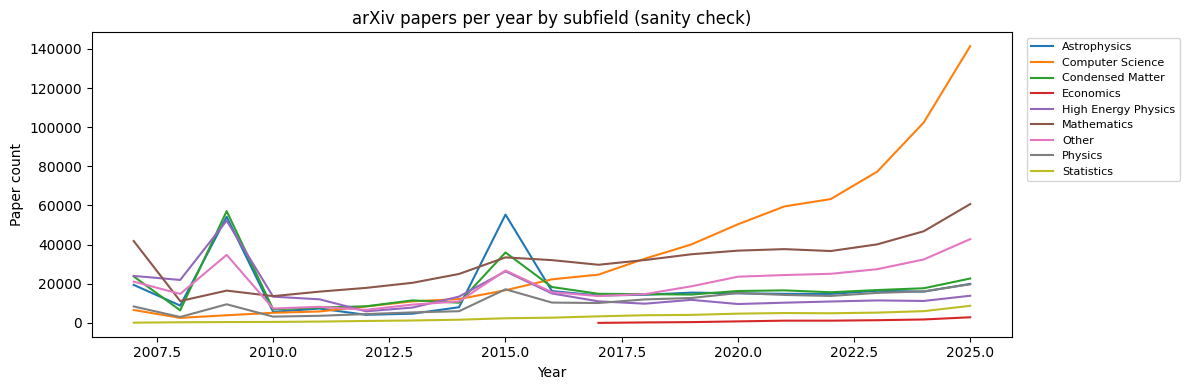

Notebook 1 complete. Output: data/papers.csv


In [26]:
# ── QUICK SANITY PLOT ────────────────────────────────────────────────
import matplotlib.pyplot as plt

yearly = (
    papers.groupby(['year', 'subfield'])
    .size()
    .reset_index(name='count')
)
fig, ax = plt.subplots(figsize=(12, 4))
for sf, grp in yearly.groupby('subfield'):
    ax.plot(grp['year'], grp['count'], label=sf)
ax.set_title('arXiv papers per year by subfield (sanity check)')
ax.set_xlabel('Year'); ax.set_ylabel('Paper count')
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'sanity_yearly.png', dpi=100)
plt.show()
print('Notebook 1 complete. Output: data/papers.csv')
